In [1]:
import VMBQC_functions
from VMBQC_functions import *

In [13]:
co_loss = np.loadtxt('models/class_1_peaked_loss_input_byp_model')
unit_loss = np.loadtxt('models/class_1_peaked_loss_unit_model')

In [6]:
total_cost_arr_1=[]


runs_2=20
iterations=299
for r in range(runs_2):
    total_cost_arr_1.append(min(unit_loss[r*(iterations+1):(r+1)*(iterations+1)]))



mean_min_u = np.mean(total_cost_arr_1)
std_u = np.std(total_cost_arr_1)
std_u

0.000545204210190762

In [7]:
total_cost_arr_2=[]


runs_2=20
iterations=299
for r in range(runs_2):
    total_cost_arr_2.append(min(co_loss[r*(iterations+1):(r+1)*(iterations+1)]))



mean_min_c1 = np.mean(total_cost_arr_2)
std_c1 = np.std(total_cost_arr_2)
std_c1

6.118158329348966e-05

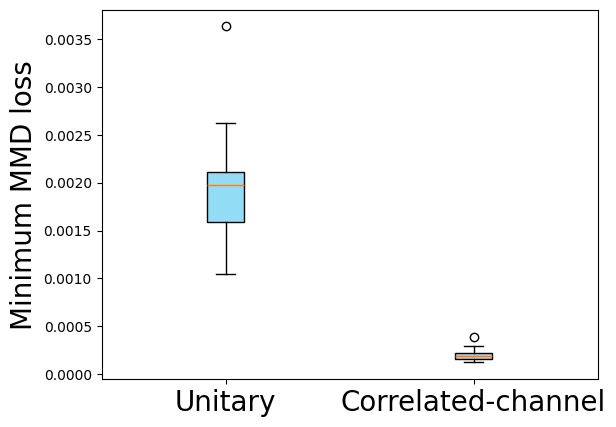

In [8]:


positions = np.arange(2)

colors = ["#93DCF5", "#BFC9D9"]

labels = [r'Unitary', r'Correlated-channel']

x_arr = [total_cost_arr_1, total_cost_arr_2]

fig, ax = plt.subplots()
ax.set_ylabel('Minimum MMD loss',fontsize=20)

bplot = ax.boxplot(x_arr,
                   patch_artist=True,  # fill with color
                   tick_labels=labels)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
plt.xticks(fontsize=20)

plt.show()

In [30]:
c_t=np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_loss_{9}.txt')
c_t.shape

(2000,)

In [20]:
p_t=np.loadtxt(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_par_{0}.txt')
sigmoid(p_t[-1])

tensor([0.8449098 , 0.98696726, 0.93087352, 0.89801162, 0.79555444,
        0.79554912, 0.77416647, 0.96495418, 0.89860828, 0.92490551,
        0.76609255, 0.99202554, 0.95628839, 0.8080558 , 0.80126412,
        0.80161461, 0.82877979, 0.88021249, 0.85826446, 0.82582056,
        0.72444348, 0.38661631, 0.68023842, 0.55542909, 0.68506884,
        0.80186974, 0.64297915, 0.658578  , 0.70664503, 0.4845197 ,
        0.54616914, 0.34221669, 0.44806727, 0.79538243, 0.77070985,
        0.83995806, 0.655738  , 0.84648353, 0.6884188 , 0.78171101], requires_grad=True)

In [18]:
from matplotlib.animation import FuncAnimation, PillowWriter


def load_and_reshape(txt_file):
    arr = sigmoid(np.loadtxt(txt_file)[:, :qubits * depth])
    if arr.ndim != 2 or arr.shape[1] != depth*qubits:
        raise ValueError("Expected (n_frames, 56) shape")
    # Reshape to (frames, rows=7, cols=8) — which matches your arr.reshape(-1,7,8)
    return arr.reshape(-1, depth, qubits)

def animate_grid(frames, output=f'new_models/p_evol_plots/{k}_qubit_p_target_etilde_learningmodel.gif', fps=10, cmap='hot'):
    n_frames, rows, cols = frames.shape  # rows=7, cols=8
    fig, ax = plt.subplots()
    
    # Transpose the first frame for correct axes orientation
    im = ax.imshow(frames[0].T,
                   vmin=frames.min(), vmax=frames.max(),
                   cmap=cmap, aspect='auto')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Probabilities')
    ax.set_title(f'Frame 1/{n_frames}')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Qubit')

    def update(i):
        im.set_data(frames[i].T)  # Transpose each frame before plotting
        ax.set_title(f'Evolution of probs at epoch {i+1}/{n_frames}')
        return (im,)

    anim = FuncAnimation(fig, update, frames=n_frames,
                         interval=1000/fps, blit=True)
    writer = PillowWriter(fps=fps)
    anim.save(output, writer=writer)
    plt.close(fig)
    print(f"✅ GIF saved as '{output}'")

if __name__ == "__main__":
    data3d = load_and_reshape(f'new_models/qubitwise_target/{k}_qubit_p_target_etilde_learningmodel_par_{0}.txt'
                             )
    animate_grid(data3d, fps=10)

✅ GIF saved as 'new_models/p_evol_plots/0_qubit_p_target_etilde_learningmodel.gif'


In [98]:
np.savetxt(f'unit_5q_etilde_layer_{k}_1_p_target_loss.txt', cost_arr)
np.savetxt(f'unit_5q_etilde_layer_{k}_1_p_target_par.txt', params_arr)

In [6]:
par_model = np.loadtxt(f'etilde_5q_etilde_all_same_p_target_par_{4}.txt')

In [55]:
sigmoid(params_arr[-1])

tensor([0.89734693, 0.99183773, 0.95576729, 0.93389926, 0.86195247,
        0.86194857, 0.84616755, 0.97786667, 0.93430133, 0.95183728,
        0.84013622, 0.99501522, 0.97230211, 0.87105183, 0.86611986,
        0.86637505, 0.88593433, 0.921818  , 0.90668497, 0.88382444,
        0.6708102 , 0.50987329, 0.59679844, 0.61452177, 0.63554228,
        0.70789352, 0.52490523, 0.64890594, 0.66650153, 0.48661639,
        0.66985786, 0.5176338 , 0.49126563, 0.74056075, 0.37632773,
        0.71267199, 0.59979526, 0.499436  , 0.68659142, 0.63182744], requires_grad=True)

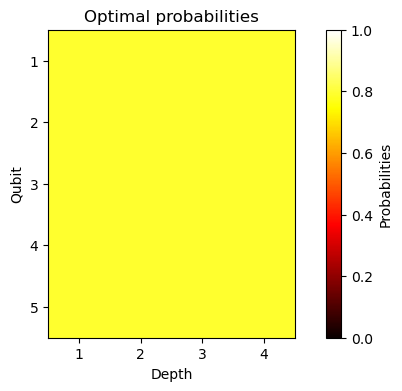

In [8]:
gen_prob_par(par_model[-1][:qubits*depth],qubits,depth)

In [75]:
cost_arr=np.loadtxt(f'etilde_5q_etilde_layer_{k}_1_p_target_loss_{8}.txt')
len(cost_arr)

1200

In [99]:
cost_arr1 = np.concatenate([np.loadtxt(f'etilde_5q_etilde_layer_{k}_1_p_target_loss_{r}.txt') for r in [4,8,9]])
cost_arr_all_p=cost_arr1
cost_arr_1_p= np.loadtxt(f'unit_5q_etilde_layer_{k}_1_p_target_loss.txt')  

In [100]:
len(cost_arr1)

3000

In [101]:
ave_cost=[]
std=[]
a=[]
total_cost_arr=[]


runs_2=10
iterations=299
for r in range(runs_2):
    total_cost_arr.append(cost_arr_all_p[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a=[]
    for i in range(runs_2):
        a.append(total_cost_arr[i][j])
    std.append(np.std(a))
    ave_cost.append(np.average(a))


    
ave_cost_1=[]
std_1=[]
a_1=[]
total_cost_arr_1=[]


runs_2=10
iterations=299
for r in range(runs_2):
    total_cost_arr_1.append(cost_arr_1_p[r*(iterations+1):(r+1)*(iterations+1)])
    
for j in range((iterations+1)):
    a_1=[]
    for i in range(runs_2):
        a_1.append(total_cost_arr_1[i][j])
    std_1.append(np.std(a_1))
    ave_cost_1.append(np.average(a_1))



/tmp/ipykernel_1022715/2895580717.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.semilogy(x, y, 'k', color='navy',label='$\widetilde{\mathcal{E}}_c(p=1/2)$')
/tmp/ipykernel_1022715/2895580717.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax.semilogy(x, y_1, 'k', color='#6CDB7A',label='$U_c$')


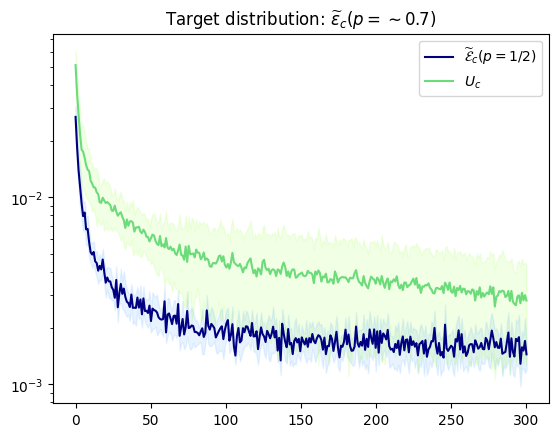

In [102]:
fig, ax = plt.subplots()
x=np.linspace(0,iterations+1,iterations+1)
y=ave_cost
yerr=std

y_1=ave_cost_1
yerr_1=std_1


ax.semilogy(x, y, 'k', color='navy',label='$\widetilde{\mathcal{E}}_c(p=1/2)$')
ax.fill_between(x, np.array(y)+np.array(yerr)/2,np.array(y)+(-1)*np.array(yerr)/2,
    alpha=0.1, edgecolor='dodgerblue', facecolor='dodgerblue')

ax.semilogy(x, y_1, 'k', color='#6CDB7A',label='$U_c$')
ax.fill_between(x, np.array(y_1)+np.array(yerr_1),np.array(y_1)+(-1)*np.array(yerr_1),
    alpha=0.1, edgecolor='#7FFF00', facecolor='#7FFF00')
plt.title(r'Target distribution: $\widetilde{\epsilon}_{c}(p=\sim0.7)$')
# plt.ylim(0.00000007,0.1)
plt.legend()
plt.show()

In [103]:
########## ******  The actual plot with 4 graphs of double gaussian is available in my desktop and not in gorka's workstation

In [272]:

import gc

mmd_grad(params).cpu()
del mmd_grad
gc.collect()
torch.cuda.empty_cache()
